In [1]:
import sys
sys.path.append('..')
from Main.Experiment_class import *
from Utils.theoretical_points import get_th_approx_data, snr_exp, snr_th

In [2]:
markersize = 15
capsize = 6
capthick = 2
linewidth = 7.5
elinewidth=2

In [3]:
obj = PIcode_experiment(None, False, False)
obj.load('../Data/31st_August_Torino_run1.json')

In [4]:
times = np.linspace(0, 300, 601)
relaxation_time = 30
delays = obj.storage['bare_qubit']['delays']

# Batches

In [5]:
N = 52000
N_bare = 2000
n = 12
obj._post_process(n)

# EXP Data

In [6]:
fids_set_1_ket0 = np.array(obj.storage[f'multi_qec_30_0']['fids'][4])
fids_set_1_ket1 = np.array(obj.storage[f'multi_qec_30_1']['fids'][4])
fids_set_2_ket0 = np.array(obj.storage[f'multi_qec_30_0']['fids'][5])
fids_set_2_ket1 = np.array(obj.storage[f'multi_qec_30_1']['fids'][5])
fids_set_3_ket0 = np.array(obj.storage[f'multi_qec_30_0']['fids'][6])
fids_set_3_ket1 = np.array(obj.storage[f'multi_qec_30_1']['fids'][6])
fid_stds_set_1_ket0 = np.array(obj.storage[f'multi_qec_30_0']['fids_stds'][4])
fid_stds_set_1_ket1 = np.array(obj.storage[f'multi_qec_30_1']['fids_stds'][4])
fid_stds_set_2_ket0 = np.array(obj.storage[f'multi_qec_30_0']['fids_stds'][5])
fid_stds_set_2_ket1 = np.array(obj.storage[f'multi_qec_30_1']['fids_stds'][5])
fid_stds_set_3_ket0 = np.array(obj.storage[f'multi_qec_30_0']['fids_stds'][6])
fid_stds_set_3_ket1 = np.array(obj.storage[f'multi_qec_30_1']['fids_stds'][6])

In [7]:
p_set_1_ket0 = np.array(obj.storage['multi_qec_30_0']['success_rates'][4])
p_set_1_ket1 = np.array(obj.storage['multi_qec_30_1']['success_rates'][4])
p_set_2_ket0 = np.array(obj.storage['multi_qec_30_0']['success_rates'][5])
p_set_2_ket1 = np.array(obj.storage['multi_qec_30_1']['success_rates'][5])
p_set_3_ket0 = np.array(obj.storage['multi_qec_30_0']['success_rates'][6])
p_set_3_ket1 = np.array(obj.storage['multi_qec_30_1']['success_rates'][6])

In [8]:
bare_qubit_fids = np.array(obj.storage['bare_qubit']['fids'][58])
bare_stds = np.array(obj.storage['bare_qubit']['fids_stds'][58])
bare_snr_set_1 = [ snr_exp(f, s, N_bare/n) for f, s in zip(bare_qubit_fids, bare_stds) ]
bare_qubit_fids = np.array(obj.storage['bare_qubit']['fids'][33])
bare_stds = np.array(obj.storage['bare_qubit']['fids_stds'][33])
bare_snr_set_2 = [ snr_exp(f, s, N_bare/n) for f, s in zip(bare_qubit_fids, bare_stds) ]
bare_qubit_fids = np.array(obj.storage['bare_qubit']['fids'][101])
bare_stds = np.array(obj.storage['bare_qubit']['fids_stds'][101])
bare_snr_set_3 = [ snr_exp(f, s, N_bare/n) for f, s in zip(bare_qubit_fids, bare_stds) ]

In [9]:
snr_set_1_ket0 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_set_1_ket0, fid_stds_set_1_ket0)
])
snr_set_1_ket1 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_set_1_ket1, fid_stds_set_1_ket1)
])
snr_set_2_ket0 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_set_2_ket0, fid_stds_set_2_ket0)
])
snr_set_2_ket1 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_set_2_ket1, fid_stds_set_2_ket1)
])
snr_set_3_ket0 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_set_3_ket0, fid_stds_set_3_ket0)
])
snr_set_3_ket1 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_set_3_ket1, fid_stds_set_3_ket1)
])

# Simulation Data

In [17]:
def rm_middle_points(data, points):
    nd = [data[0]]
    for i in range (1, points):
        if i % 2 == 0:
            nd.append(data[i])
    return nd


In [18]:
obj_sim1 = PIcode_experiment(None, False, False)
obj_sim1.load('../Data/Set1_simulation.json')
delays_sim = obj_sim1.storage['bare_qubit']['delays']
obj_sim1._post_process(n)

In [32]:
fids_sim_set_1_ket0 = np.array(obj_sim1.storage[f'multi_qec_30_0']['fids'][0])
fids_sim_set_1_ket1 = np.array(obj_sim1.storage[f'multi_qec_30_1']['fids'][0])
fids_sim_stds_set_1_ket0 = np.array(obj_sim1.storage[f'multi_qec_30_0']['fids_stds'][0])
fids_sim_stds_set_1_ket1 = np.array(obj_sim1.storage[f'multi_qec_30_1']['fids_stds'][0])
p_sim_set_1_ket0 = np.array(obj_sim1.storage[f'multi_qec_30_0']['success_rates'][0])
p_sim_set_1_ket1 = np.array(obj_sim1.storage[f'multi_qec_30_1']['success_rates'][0])
snr_sim_set_1_ket0 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_sim_set_1_ket0, fids_sim_stds_set_1_ket0)
])
snr_sim_set_1_ket1 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_sim_set_1_ket1, fids_sim_stds_set_1_ket1)
])
bare_qubit_fids_sim = np.array(obj_sim1.storage[f'bare_qubit']['fids'][1])
bare_stds_sim = np.array(obj_sim1.storage['bare_qubit']['fids_stds'][1])
bare_snr_set_1_sim = [ snr_exp(f, s, N_bare/n) for f, s in zip(bare_qubit_fids_sim, bare_stds_sim) ]

In [34]:
snr_sim_set_1_ket0 = np.array(rm_middle_points(snr_sim_set_1_ket0, 61))
snr_sim_set_1_ket1 = np.array(rm_middle_points(snr_sim_set_1_ket1, 61))
bare_snr_set_1_sim = np.array(rm_middle_points(bare_snr_set_1_sim, 61))

In [12]:
obj_sim2 = PIcode_experiment(None, False, False)
obj_sim2.load('../Data/Set2_simulation.json')
delays_sim = obj_sim2.storage['bare_qubit']['delays']
obj_sim2._post_process(n)

In [13]:
fids_sim_set_2_ket0 = np.array(obj_sim2.storage[f'multi_qec_30_0']['fids'][0])
fids_sim_set_2_ket1 = np.array(obj_sim2.storage[f'multi_qec_30_1']['fids'][0])
fids_sim_stds_set_2_ket0 = np.array(obj_sim2.storage[f'multi_qec_30_0']['fids_stds'][0])
fids_sim_stds_set_2_ket1 = np.array(obj_sim2.storage[f'multi_qec_30_1']['fids_stds'][0])
p_sim_set_2_ket0 = np.array(obj_sim2.storage[f'multi_qec_30_0']['success_rates'][0])
p_sim_set_2_ket1 = np.array(obj_sim2.storage[f'multi_qec_30_1']['success_rates'][0])
snr_sim_set_2_ket0 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_sim_set_2_ket0, fids_sim_stds_set_2_ket0)
])
snr_sim_set_2_ket1 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_sim_set_2_ket1, fids_sim_stds_set_2_ket1)
])
bare_qubit_fids_sim = np.array(obj_sim2.storage[f'bare_qubit']['fids'][1])
bare_stds_sim = np.array(obj_sim2.storage['bare_qubit']['fids_stds'][1])
bare_snr_set_2_sim = [ snr_exp(f, s, N_bare/n) for f, s in zip(bare_qubit_fids_sim, bare_stds_sim) ]

In [39]:
snr_sim_set_2_ket0 = np.array(rm_middle_points(snr_sim_set_2_ket0, 61))
snr_sim_set_2_ket1 = np.array(rm_middle_points(snr_sim_set_2_ket1, 61))
bare_snr_set_2_sim = np.array(rm_middle_points(bare_snr_set_2_sim, 61))

In [14]:
obj_sim3 = PIcode_experiment(None, False, False)
obj_sim3.load('../Data/Set3_simulation.json')
delays_sim = obj_sim3.storage['bare_qubit']['delays']
obj_sim3._post_process(n)

In [15]:
fids_sim_set_3_ket0 = np.array(obj_sim3.storage[f'multi_qec_30_0']['fids'][0])
fids_sim_set_3_ket1 = np.array(obj_sim3.storage[f'multi_qec_30_1']['fids'][0])
fids_sim_stds_set_3_ket0 = np.array(obj_sim3.storage[f'multi_qec_30_0']['fids_stds'][0])
fids_sim_stds_set_3_ket1 = np.array(obj_sim3.storage[f'multi_qec_30_1']['fids_stds'][0])
p_sim_set_3_ket0 = np.array(obj_sim3.storage[f'multi_qec_30_0']['success_rates'][0])
p_sim_set_3_ket1 = np.array(obj_sim3.storage[f'multi_qec_30_1']['success_rates'][0])
snr_sim_set_3_ket0 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_sim_set_3_ket0, fids_sim_stds_set_3_ket0)
])
snr_sim_set_3_ket1 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_sim_set_3_ket1, fids_sim_stds_set_3_ket1)
])
bare_qubit_fids_sim = np.array(obj_sim3.storage[f'bare_qubit']['fids'][1])
bare_stds_sim = np.array(obj_sim3.storage['bare_qubit']['fids_stds'][1])
bare_snr_set_3_sim = [ snr_exp(f, s, N_bare/n) for f, s in zip(bare_qubit_fids_sim, bare_stds_sim) ]

In [43]:
snr_sim_set_3_ket0 = np.array(rm_middle_points(snr_sim_set_3_ket0, 61))
snr_sim_set_3_ket1 = np.array(rm_middle_points(snr_sim_set_3_ket1, 61))
bare_snr_set_3_sim = np.array(rm_middle_points(bare_snr_set_3_sim, 61))

# SET 1

In [16]:
set1_T1 = 205
set1_T2 = 90
qubit_set1 = obj.storage['multi_qec_30_1']['qubit_pos'][4]
bare_f_measure = [obj.storage['bare_qubit']['fids'][qubit][0] for qubit in qubit_set1]

In [17]:
1 - np.mean(bare_f_measure)

np.float64(0.03632734530938131)

In [18]:
data_set1 = get_th_approx_data(set1_T1, set1_T2, times, relaxation_time)
bare_snr_set_1_th = snr_th(f=data_set1['bare_qubit']['fids'], p=1.0, f_measure=bare_f_measure[1], n_measure=1)
snr_set_1_ket0_th = snr_th(f=data_set1['multi_qec_0_approx']['fids'], p=data_set1['multi_qec_0_approx']['probs'], f_measure=np.mean(bare_f_measure), n_measure=4)
snr_set_1_ket1_th = snr_th(f=data_set1['multi_qec_1_approx']['fids'], p=data_set1['multi_qec_1_approx']['probs'], f_measure=np.mean(bare_f_measure), n_measure=4)
# snr_set_1_ket0_th = snr_th(f=data_set1['multi_qec_0_approx']['fids'], p=np.array(obj2.storage[f'multi_qec_30_0']['success_rates']['0']), f_measure=np.mean(bare_f_measure), n_measure=4)
# snr_set_1_ket1_th = snr_th(f=data_set1['multi_qec_1_approx']['fids'], p=np.array(obj2.storage[f'multi_qec_30_1']['success_rates']['0']), f_measure=np.mean(bare_f_measure), n_measure=4)

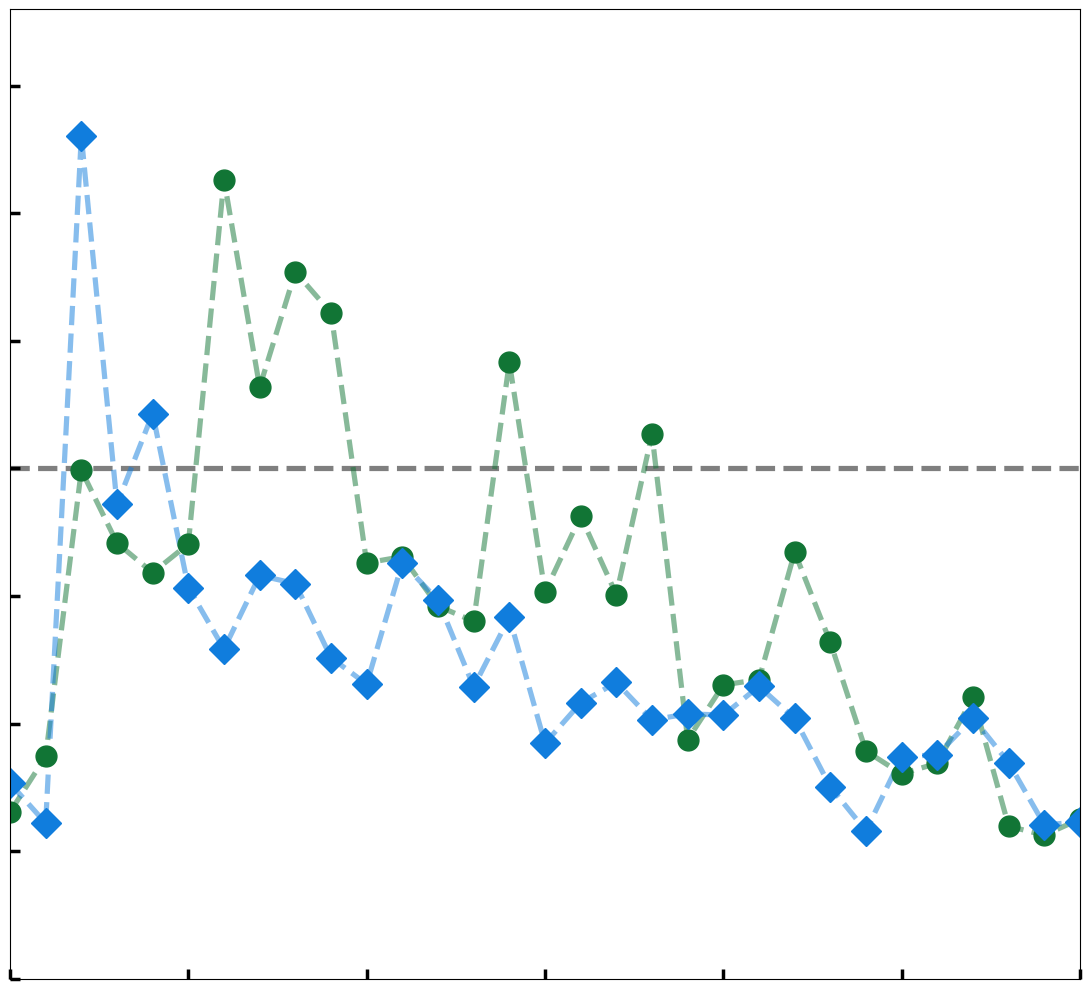

In [46]:
plt.figure(figsize=(11, 10))
plt.axhline(y = 1.0, color = 'k', ls = '--', lw = linewidth/2, alpha = 0.5)
# plt.errorbar(delays, snr_set_1_ket0/bare_snr_set_1, yerr = None, fmt='o', color = '#11753544', ecolor = '#11753544', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|0\rangle$ EXP', ls = None)
# plt.errorbar(delays, snr_set_1_ket1/bare_snr_set_1, yerr = None, fmt='D', color = '#107DDD44', ecolor = '#107DDD44', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|1\rangle$ EXP', ls = None)
# plt.plot(delays, snr_set_1_ket0/bare_snr_set_1, color = '#117535', ls='--', alpha = 0.5, lw=linewidth/2)
# plt.plot(delays, snr_set_1_ket1/bare_snr_set_1, color = '#107DDD44', ls='--', alpha = 0.5, lw=linewidth/2)
# plt.plot(times, snr_set_1_ket0_th/bare_snr_set_1_th, label = r'$|0\rangle$ Theoretical', ls='-', color = '#117535', linewidth = linewidth, alpha = 0.8)
# plt.plot(times, snr_set_1_ket1_th/bare_snr_set_1_th, label = r'$|1\rangle$ Theoretical', ls='-', color= '#107DDD', linewidth = linewidth, alpha = 0.8)

plt.errorbar(delays, snr_sim_set_1_ket0/bare_snr_set_1_sim, yerr = None, fmt='o', color = "#117535", ecolor = '#117535', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|0\rangle$ EXP', ls = None)
plt.errorbar(delays, snr_sim_set_1_ket1/bare_snr_set_1_sim, yerr = None, fmt='D', color = "#107DDD", ecolor = '#107DDD', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|1\rangle$ EXP', ls = None)
plt.plot(delays, snr_sim_set_1_ket0/bare_snr_set_1_sim, color = '#117535', ls='--', alpha = 0.5, lw=linewidth/2)
plt.plot(delays, snr_sim_set_1_ket1/bare_snr_set_1_sim, color = '#107DDD', ls='--', alpha = 0.5, lw=linewidth/2)

plt.xlim(0, 300)
plt.ylim(0, 1.9)
# plt.legend(fontsize = 20)
# plt.tick_params(axis='both', direction='in', labelsize = 20, width = 2.5, size = 7.5)
plt.tick_params(axis='both', direction='in', labelsize = 0, width = 2.5, size = 7.5, labelleft = False, labelbottom = False)
# plt.xlabel('Delay [μs]', fontsize = 24)
# plt.ylabel(r'Gain', fontsize = 24)
plt.tight_layout()
plt.savefig('simulation_gain_Set_1_empty.pdf', bbox_inches='tight', pad_inches=0, dpi = 300)

# SET 2

In [16]:
set2_T1 = 240
set2_T2 = 70
qubit_set2 = obj.storage['multi_qec_30_1']['qubit_pos'][5]
bare_f_measure_2 = [obj.storage['bare_qubit']['fids'][qubit][0] for qubit in qubit_set2]

In [17]:
1 - np.mean(bare_f_measure_2)

np.float64(0.026247504990019932)

In [18]:
data_set2 = get_th_approx_data(set2_T1, set2_T2, times, relaxation_time)
bare_snr_set_2_th = snr_th(f=data_set2['bare_qubit']['fids'], p=1.0, f_measure=bare_f_measure_2[1], n_measure=1)
snr_set_2_ket0_th = snr_th(f=data_set2['multi_qec_0_approx']['fids'], p=data_set2['multi_qec_0_approx']['probs'], f_measure=np.mean(bare_f_measure_2), n_measure=4)
snr_set_2_ket1_th = snr_th(f=data_set2['multi_qec_1_approx']['fids'], p=data_set2['multi_qec_1_approx']['probs'], f_measure=np.mean(bare_f_measure_2), n_measure=4)
# snr_set_2_ket0_th = snr_th(f=data_set2['multi_qec_0_approx']['fids'], p=np.array(obj.storage[f'multi_qec_30_0']['success_rates'][5]), f_measure=np.mean(bare_f_measure_2), n_measure=4)
# snr_set_2_ket1_th = snr_th(f=data_set2['multi_qec_1_approx']['fids'], p=np.array(obj.storage[f'multi_qec_30_1']['success_rates'][5]), f_measure=np.mean(bare_f_measure_2), n_measure=4)

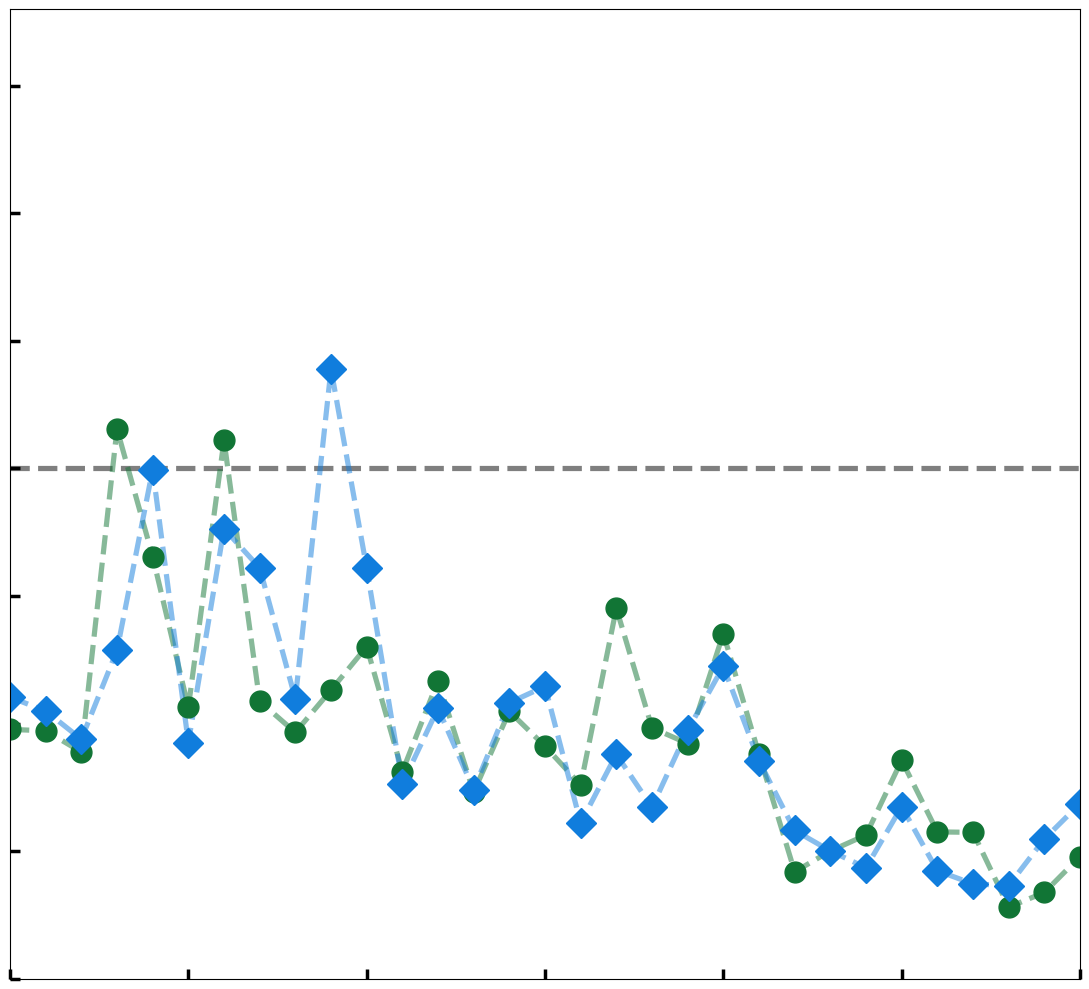

In [47]:
plt.figure(figsize=(11, 10))
plt.axhline(y = 1.0, color = 'k', ls = '--', lw = linewidth/2, alpha = 0.5)
# plt.errorbar(delays, snr_set_2_ket0/bare_snr_set_2, yerr = None, fmt='o', color = '#117535', ecolor = '#117535', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|0\rangle$ EXP', ls = None)
# plt.errorbar(delays, snr_set_2_ket1/bare_snr_set_2, yerr = None, fmt='D', color = '#107DDD', ecolor = '#107DDD', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|1\rangle$ EXP', ls = None)
# plt.plot(delays, snr_set_2_ket0/bare_snr_set_2, color = '#117535', ls='--', alpha = 0.5, lw=linewidth/2)
# plt.plot(delays, snr_set_2_ket1/bare_snr_set_2, color = '#107DDD', ls='--', alpha = 0.5, lw=linewidth/2)
# plt.plot(times, snr_set_2_ket0_th/bare_snr_set_2_th, label = r'$|0\rangle$ Theoretical', ls='-', color = '#117535', linewidth = linewidth, alpha = 0.8)
# plt.plot(times, snr_set_2_ket1_th/bare_snr_set_2_th, label = r'$|1\rangle$ Theoretical', ls='-', color= '#107DDD', linewidth = linewidth, alpha = 0.8)

plt.errorbar(delays, snr_sim_set_2_ket0/bare_snr_set_2_sim, yerr = None, fmt='o', color = "#117535", ecolor = '#117535', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|0\rangle$ EXP', ls = None)
plt.errorbar(delays, snr_sim_set_2_ket1/bare_snr_set_2_sim, yerr = None, fmt='D', color = "#107DDD", ecolor = '#107DDD', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|1\rangle$ EXP', ls = None)
plt.plot(delays, snr_sim_set_2_ket0/bare_snr_set_2_sim, color = '#117535', ls='--', alpha = 0.5, lw=linewidth/2)
plt.plot(delays, snr_sim_set_2_ket1/bare_snr_set_2_sim, color = '#107DDD', ls='--', alpha = 0.5, lw=linewidth/2)

plt.xlim(0, 300)
plt.ylim(0, 1.9)
plt.tick_params(axis='both', direction='in', labelsize = 0, width = 2.5, size = 7.5, labelleft = False, labelbottom = False)
# plt.legend(fontsize = 20)
# plt.tick_params(axis='both', direction='in', labelsize = 20, width = 2.5, size = 7.5)
# plt.xlabel('Delay [μs]', fontsize = 24)
# plt.ylabel(r'Gain', fontsize = 24)
plt.tight_layout()
plt.savefig('simulation_gain_Set_2_empty.pdf', bbox_inches='tight', pad_inches=0, dpi = 300)

# SET 3

In [20]:
set3_T1 = 245
set3_T2 = 95
qubit_set3 = obj.storage['multi_qec_30_1']['qubit_pos'][6]
bare_f_measure_3 = [obj.storage['bare_qubit']['fids'][qubit][0] for qubit in qubit_set3]

In [21]:
1 - np.mean(bare_f_measure_3)

np.float64(0.03313373253493013)

In [22]:
data_set3 = get_th_approx_data(set3_T1, set3_T2, times, relaxation_time)
bare_snr_set_3_th = snr_th(f=data_set3['bare_qubit']['fids'], p=1.0, f_measure=bare_f_measure_3[1], n_measure=1)
snr_set_3_ket0_th = snr_th(f=data_set3['multi_qec_0_approx']['fids'], p=data_set3['multi_qec_0_approx']['probs'], f_measure=np.mean(bare_f_measure_3), n_measure=4)
snr_set_3_ket1_th = snr_th(f=data_set3['multi_qec_1_approx']['fids'], p=data_set3['multi_qec_1_approx']['probs'], f_measure=np.mean(bare_f_measure_3), n_measure=4)
# snr_set_2_ket0_th = snr_th(f=data_set2['multi_qec_0_approx']['fids'], p=np.array(obj.storage[f'multi_qec_30_0']['success_rates'][5]), f_measure=np.mean(bare_f_measure_2), n_measure=4)
# snr_set_2_ket1_th = snr_th(f=data_set2['multi_qec_1_approx']['fids'], p=np.array(obj.storage[f'multi_qec_30_1']['success_rates'][5]), f_measure=np.mean(bare_f_measure_2), n_measure=4)

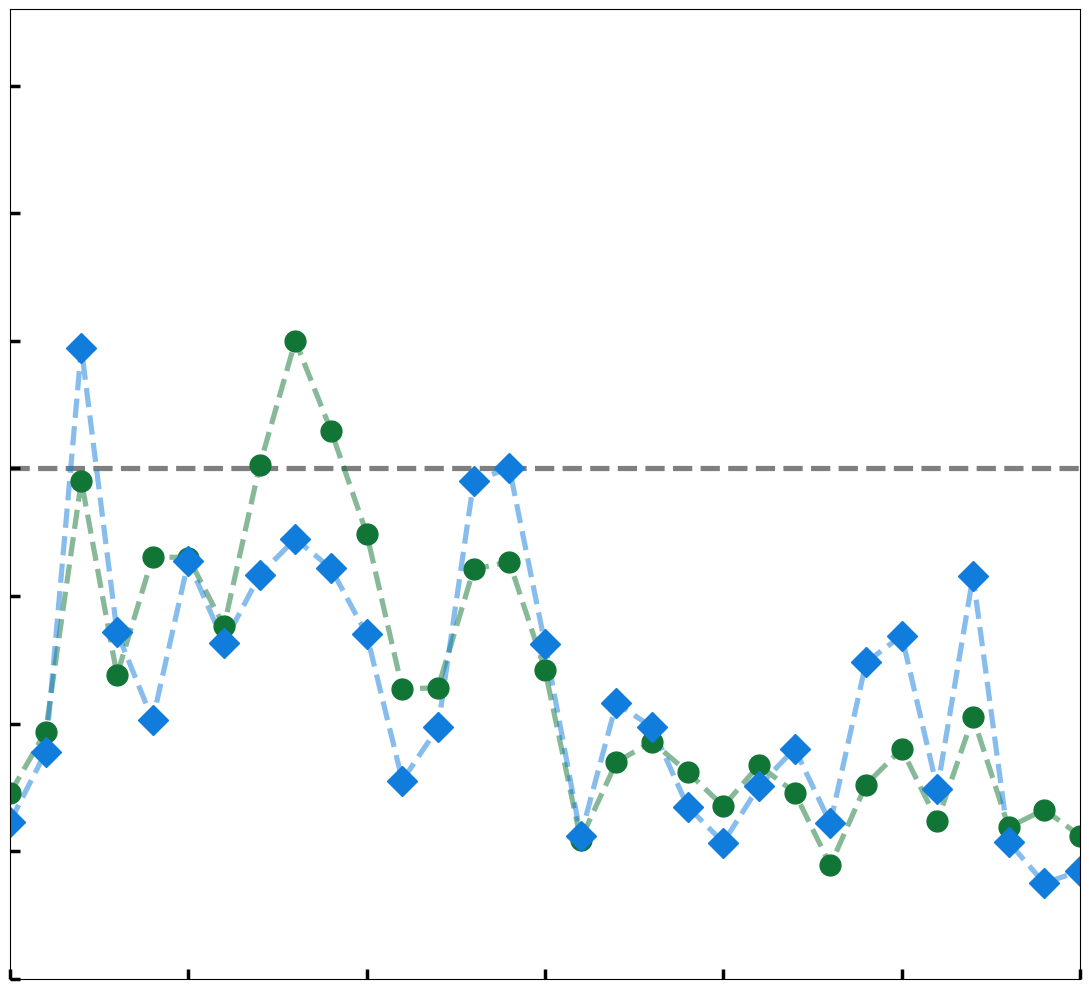

In [48]:
plt.figure(figsize=(11, 10))
plt.axhline(y = 1.0, color = 'k', ls = '--', lw = linewidth/2, alpha = 0.5)
# plt.errorbar(delays, snr_set_3_ket0/bare_snr_set_3, yerr = None, fmt='o', color = '#117535', ecolor = '#117535', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|0\rangle$ EXP', ls = None)
# plt.errorbar(delays, snr_set_3_ket1/bare_snr_set_3, yerr = None, fmt='D', color = '#107DDD', ecolor = '#107DDD', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|1\rangle$ EXP', ls = None)
# plt.plot(delays, snr_set_3_ket0/bare_snr_set_3, color = '#117535', ls='--', alpha = 0.5, lw=linewidth/2)
# plt.plot(delays, snr_set_3_ket1/bare_snr_set_3, color = '#107DDD', ls='--', alpha = 0.5, lw=linewidth/2)
# plt.plot(times, snr_set_3_ket0_th/bare_snr_set_3_th, label = r'$|0\rangle$ Theoretical', ls='-', color = '#117535', linewidth = linewidth, alpha = 0.8)
# plt.plot(times, snr_set_3_ket1_th/bare_snr_set_3_th, label = r'$|1\rangle$ Theoretical', ls='-', color= '#107DDD', linewidth = linewidth, alpha = 0.8)

plt.errorbar(delays, snr_sim_set_3_ket0/bare_snr_set_3_sim, yerr = None, fmt='o', color = "#117535", ecolor = '#117535', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|0\rangle$ EXP', ls = None)
plt.errorbar(delays, snr_sim_set_3_ket1/bare_snr_set_3_sim, yerr = None, fmt='D', color = "#107DDD", ecolor = '#107DDD', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|1\rangle$ EXP', ls = None)
plt.plot(delays, snr_sim_set_3_ket0/bare_snr_set_3_sim, color = '#117535', ls='--', alpha = 0.5, lw=linewidth/2)
plt.plot(delays, snr_sim_set_3_ket1/bare_snr_set_3_sim, color = '#107DDD', ls='--', alpha = 0.5, lw=linewidth/2)

plt.xlim(0, 300)
plt.ylim(0, 1.9)
plt.tick_params(axis='both', direction='in', labelsize = 0, width = 2.5, size = 7.5, labelleft = False, labelbottom = False)
# plt.legend(fontsize = 20)
# plt.tick_params(axis='both', direction='in', labelsize = 20, width = 2.5, size = 7.5)
# plt.xlabel('Delay [μs]', fontsize = 24)
# plt.ylabel(r'Gain', fontsize = 24)
plt.tight_layout()
plt.savefig('simulation_gain_Set_3_empty.pdf', bbox_inches='tight', pad_inches=0, dpi = 300)